<a href="https://colab.research.google.com/github/ihmkusuma/machine-learning-assignment-ilham-kusuma-4222311030/blob/main/Working%20on%20Machine%20Learning/Transfer%20Learning%20Trash%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification using Transfer Learning
## Deteksi Jenis Sampah di Sekitar Kampus

**Ilham Kusuma | 4222311030 | TRR 6A Pagi**

**Dataset:** [Trash Type Image Dataset (Kaggle)](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)

**Tujuan:**
1. Membangun model klasifikasi jenis sampah menggunakan Transfer Learning (pre-trained CNN).
2. Mengevaluasi apakah model mengalami overfitting.
3. Jika overfitting terjadi, menerapkan teknik penanganan overfitting (dropout, regularization, augmentation, early stopping, fine-tuning bertahap).

### Alur Kerja
```
Dataset → Augmentasi → Fixed Feature Extractor → Cek Overfitting
       → Dropout + Regularization + Early Stopping
       → Fine-Tuning Bertahap → Evaluasi Akhir

## 1. Setup & Download Dataset

Download dataset dari Kaggle terlebih dahulu di laptop (dalam bentuk file `.zip`, tidak perlu di-extract), lalu jalankan sel di bawah ini dan pilih file zip tersebut untuk diupload.

In [1]:
from google.colab import files
uploaded = files.upload()  # pilih file .zip dataset trash-type kamu di sini

Saving Garbage Image Dataset.zip to Garbage Image Dataset.zip


In [2]:
import zipfile, os

# Ambil nama file zip yang baru saja diupload
zip_filename = list(uploaded.keys())[0]
print('Garbage Image Dataset.zip', zip_filename)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('trash_data')

print('\nIsi folder trash_data setelah extract:')
print(os.listdir('trash_data'))

Garbage Image Dataset.zip Garbage Image Dataset.zip

Isi folder trash_data setelah extract:
['TrashType_Image_Dataset']


**Catatan:** Beberapa dataset Kaggle setelah di-extract punya struktur folder bersarang (misal `trash_data/dataset/garbage_classification/...`). Jalankan sel di atas, lihat output `os.listdir('trash_data')`, lalu sesuaikan path `data_dir` di Bagian 3 jika ternyata foldernya tidak langsung berisi kelas-kelas sampah (cardboard, glass, metal, dll), melainkan ada subfolder lagi di dalamnya.

## 2. Import Library

Pada tahap ini kita mengimpor seluruh library yang dibutuhkan sepanjang eksperimen:
- **TensorFlow / Keras**: framework utama untuk membangun dan melatih model deep learning.
- **ResNet50V2**: arsitektur pre-trained yang akan digunakan sebagai base model Transfer Learning. ResNet50V2 dipilih karena menggunakan *skip connections* yang memungkinkan jaringan sangat dalam dilatih tanpa masalah *vanishing gradient*.
- **ImageDataGenerator**: untuk augmentasi data dan pembagian train/validasi.
- **Callbacks (EarlyStopping, ReduceLROnPlateau)**: pengontrol otomatis proses training.
- **matplotlib & seaborn**: untuk visualisasi grafik training dan confusion matrix.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU tersedia:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: []


> **Mengapa ResNet50V2 bukan ResNet18?** Keras Applications tidak menyediakan ResNet18 secara bawaan. ResNet50V2 adalah pilihan terdekat yang tersedia, bahkan lebih baik karena memiliki 50 layer dan menggunakan arsitektur V2 yang menempatkan Batch Normalization sebelum aktivasi — terbukti memberikan performa lebih baik daripada versi V1. Model ini telah dilatih pada **ImageNet** (14 juta gambar, 1000 kelas), sehingga sudah mengenal fitur-fitur visual umum seperti tepi, tekstur, hingga bentuk objek kompleks.

## 3. Eksplorasi Dataset
Sebelum melatih model, penting untuk memahami distribusi data terlebih dahulu. Kita perlu mengetahui:
- Berapa banyak kelas (jenis sampah) yang ada dalam dataset.
- Seberapa banyak sampel gambar per kelas — distribusi yang tidak merata (*imbalanced*) dapat memengaruhi performa model.
- Seperti apa tampilan visual gambar dari masing-masing kelas.

In [4]:
# Sesuaikan path ini dengan struktur folder hasil unzip
data_dir = 'trash_data/TrashType_Image_Dataset'

print('Daftar kelas dan jumlah sampel:')
total = 0
for cls in sorted(os.listdir(data_dir)):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        n = len(os.listdir(cls_path))
        total += n
        print(f'  {cls:15s}: {n} gambar')
print(f'\nTotal sampel: {total}')

Daftar kelas dan jumlah sampel:
  cardboard      : 403 gambar
  glass          : 501 gambar
  metal          : 410 gambar
  paper          : 594 gambar
  plastic        : 482 gambar
  trash          : 137 gambar

Total sampel: 2527


Berdasarkan tabel **Types of Transfer Learning** pada materi:

| Metode | Dataset Size |
|---|---|
| Fixed Feature Extractor | Kecil (<1K) |
| Fine-tuning | Sedang (1K-10K) |
| Pre-trained as Initialization | Besar (>10K) |

Dataset trash-type ini umumnya berjumlah sekitar 2500 gambar, sehingga strategi yang paling sesuai adalah **Fixed Feature Extractor sebagai tahap awal**, dilanjutkan **Fine-tuning bertahap** jika hasil awal masih kurang optimal atau overfitting.

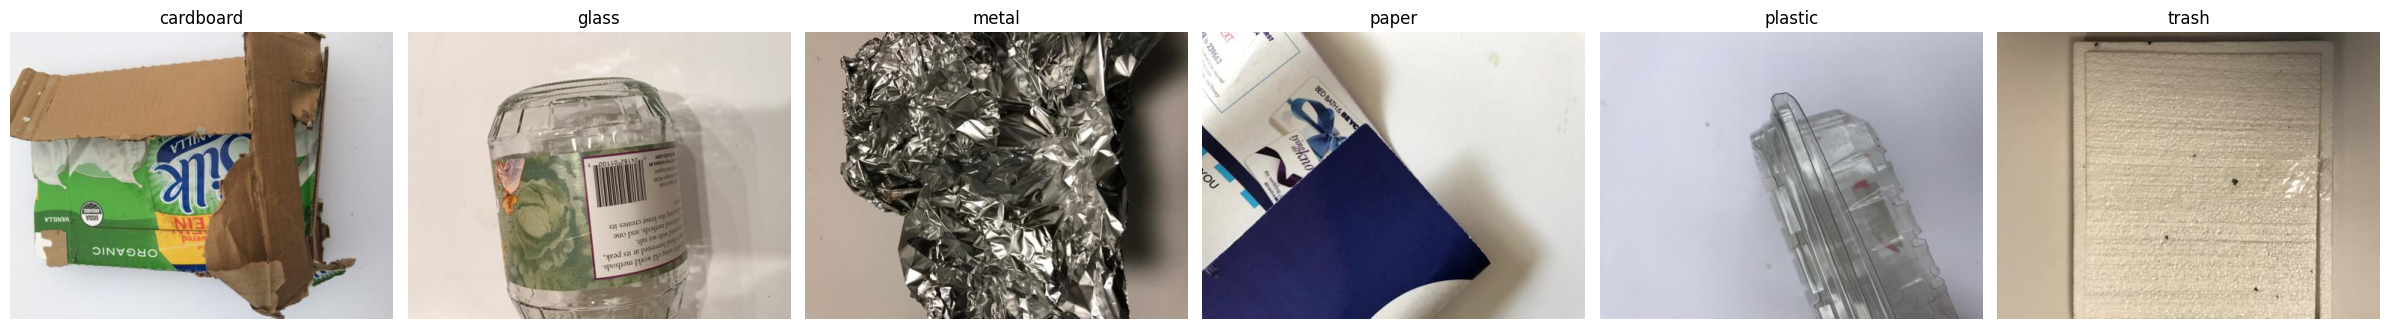

In [5]:
# Visualisasi contoh gambar tiap kelas
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
fig, axes = plt.subplots(1, len(classes), figsize=(4*len(classes), 4))
for ax, cls in zip(axes, classes):
    cls_path = os.path.join(data_dir, cls)
    img_name = os.listdir(cls_path)[0]
    img = plt.imread(os.path.join(cls_path, img_name))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Data Augmentation & Split Train/Validation
### Mengapa Data Augmentation?
Dataset yang relatif kecil (~2500 gambar) sangat rentan terhadap overfitting. Data augmentasi adalah teknik yang secara artifisial memperbesar variasi data training dengan menerapkan transformasi acak pada gambar asli — sehingga model tidak menghafal gambar yang sama persis, melainkan belajar fitur yang lebih general.

Transformasi yang diterapkan:
- `rotation_range=20` — rotasi gambar hingga ±20 derajat.
- `width_shift_range=0.1`, `height_shift_range=0.1` — pergeseran horizontal/vertikal hingga 10%.
- `shear_range=0.1` — distorsi kemiringan.
- `zoom_range=0.2` — zoom acak ±20%.
- `horizontal_flip=True` — pencerminan horizontal.
- `brightness_range=[0.8, 1.2]` — variasi kecerahan gambar.

### Split Data
Data dibagi dengan rasio **80% training : 20% validasi** menggunakan parameter `validation_split=0.2`. Validasi digunakan untuk memantau performa model pada data yang belum pernah dilihat selama training, sehingga kita bisa mendeteksi overfitting sejak dini.

### Preprocessing ResNet50V2
Fungsi `preprocess_input` dari ResNet50V2 digunakan untuk menormalisasi nilai piksel gambar sesuai distribusi yang digunakan saat ResNet50V2 dilatih pada ImageNet — penting agar bobot pre-trained dapat bekerja dengan baik pada data kita.

In [6]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

num_classes = train_gen.num_classes
class_indices = train_gen.class_indices
print('Jumlah kelas:', num_classes)
print('Mapping kelas:', class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Jumlah kelas: 6
Mapping kelas: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


## 5. Membangun Model — Fixed Feature Extractor (Tahap Awal)

### Konsep Fixed Feature Extractor
Arsitektur pre-trained (source domain) digunakan sebagai *feature extractor* dengan seluruh layer-nya di-**freeze** (tidak diupdate saat training). Hanya bagian **classifier** di akhir jaringan yang diganti dan dilatih ulang untuk mengenali kelas-kelas sampah (target domain).

Ini ibarat menggunakan "otak" yang sudah pintar mengenali fitur visual dari ImageNet, kemudian kita hanya melatih "pengambil keputusan" baru di ujungnya untuk tugas spesifik kita.

### Arsitektur Classifier Baru
Di atas output ResNet50V2 yang di-freeze, ditambahkan:
1. `GlobalAveragePooling2D` — meringkas feature map 2D menjadi vektor 1D dengan mengambil rata-rata tiap channel.
2. `Dense(128, activation='relu')` — lapisan fully-connected dengan 128 neuron dan fungsi aktivasi ReLU.
3. `Dropout(0.3)` — secara acak menonaktifkan 30% neuron saat training untuk mencegah overfitting.
4. `Dense(num_classes, activation='softmax')` — lapisan output dengan jumlah neuron sesuai kelas sampah, menggunakan softmax untuk menghasilkan probabilitas tiap kelas.

**Optimizer:** Adam dengan learning rate `1e-3` — cukup besar untuk pelatihan classifier baru yang mulai dari nol.

**Loss function:** Categorical Crossentropy — standar untuk klasifikasi multi-kelas.

In [7]:
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # freeze seluruh convolutional layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,827,846 (90.90 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

## 6. Training Tahap Awal
Model dilatih selama **20 epoch** tanpa early stopping, agar kita bisa melihat tren penuh dari kurva training vs validasi dan menilai apakah terjadi overfitting. Setiap epoch, model melewati seluruh data training satu kali (±2000 gambar) dan dievaluasi pada data validasi (±500 gambar).

In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 431s 7s/step - accuracy: 0.6601 - loss: 0.9411 - val_accuracy: 0.7654 - val_loss: 0.6690
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 419s 7s/step - accuracy: 0.8093 - loss: 0.5379 - val_accuracy: 0.7932 - val_loss: 0.5678
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 443s 7s/step - accuracy: 0.8533 - loss: 0.4063 - val_accuracy: 0.8091 - val_loss: 0.5648
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 431s 7s/step - accuracy: 0.8844 - loss: 0.3224 - val_accuracy: 0.8250 - val_loss: 0.5584
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 427s 7s/step - accuracy: 0.8844 - loss: 0.3043 - val_accuracy: 0.8151 - val_loss: 0.6273
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 416s 7s/step - accuracy: 0.9002 - loss: 0.2910 - val_accuracy: 0.8151 - val_loss: 0.5418
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 415s 7s/step - accuracy: 0.9071 - loss: 0.2392 - val_accuracy: 0.8250 - val_loss: 0.5949
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 411s 6s/step - accuracy: 0.9165 - loss: 0.2280 - val_accuracy: 0.8270 - v

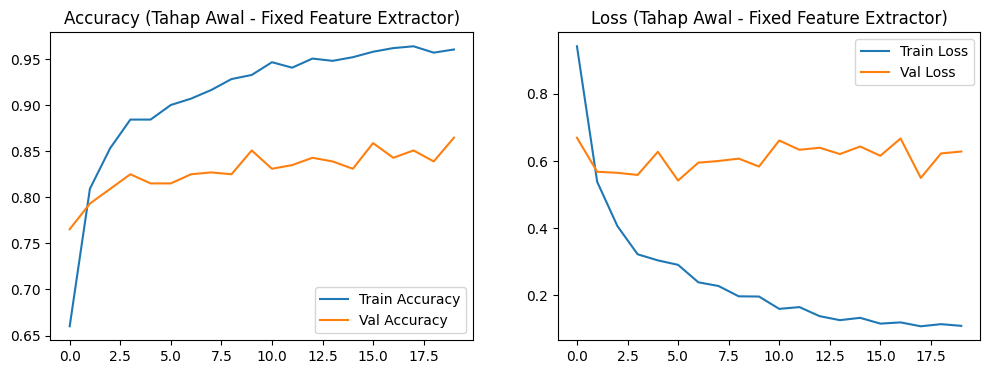

In [9]:
def plot_history(history, title_suffix=''):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'Accuracy {title_suffix}')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.legend(loc='upper right')
    plt.title(f'Loss {title_suffix}')

    plt.show()

plot_history(history, '(Tahap Awal - Fixed Feature Extractor)')

## 7. Analisis Overfitting

### Apa itu Overfitting?
Overfitting terjadi ketika model terlalu "hafal" data training sehingga kehilangan kemampuan untuk generalisasi ke data baru. Model seperti ini akan menunjukkan akurasi training yang sangat tinggi, tetapi akurasi validasi yang jauh lebih rendah.

### Indikator Overfitting dari Grafik
Perhatikan grafik Accuracy dan Loss dari training tahap awal di atas:
- **Overfitting**: kurva train accuracy terus naik mendekati 1.0 sementara val accuracy stagnan/menurun; val loss mulai naik sementara train loss terus turun.
- **Underfitting**: kedua kurva rendah dan belum stabil.
- **Fit yang baik**: kedua kurva konvergen berdekatan dan stabil.

### Indikator Kuantitatif
Gap antara train accuracy dan val accuracy di epoch terakhir digunakan sebagai ukuran sederhana:
- **Gap > 10%** → overfitting signifikan.
- **Gap ≤ 10%** → performa relatif seimbang, namun tetap perlu diperhatikan tren grafik loss.

In [10]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
gap = final_train_acc - final_val_acc

print(f'Train Accuracy akhir : {final_train_acc:.4f}')
print(f'Val Accuracy akhir   : {final_val_acc:.4f}')
print(f'Gap (Train - Val)    : {gap:.4f}')

if gap > 0.1:
    print('\n=> Indikasi OVERFITTING terdeteksi (gap > 10%). Lanjutkan ke tahap penanganan overfitting di bawah.')
else:
    print('\n=> Model belum menunjukkan overfitting signifikan. Namun tetap perhatikan tren grafik loss.')

Train Accuracy akhir : 0.9605
Val Accuracy akhir   : 0.8648
Gap (Train - Val)    : 0.0957

=> Model belum menunjukkan overfitting signifikan. Namun tetap perhatikan tren grafik loss.


## 8. Penanganan Overfitting

Meskipun gap pada Bagian 7 masih di bawah 10% (0.0957 ≈ 9.57%), selisih antara train accuracy (96.05%) dan val accuracy (86.48%) tetap cukup berarti dan mengindikasikan model belum generalisasi sepenuhnya. Oleh karena itu, teknik penanganan overfitting tetap diterapkan secara proaktif untuk memaksimalkan performa validasi.

Kombinasi teknik yang diterapkan sesuai materi di kelas:
1. **Dropout (0.5)** — dinaikkan dari 0.3 menjadi 0.5, menonaktifkan 50% neuron secara acak tiap iterasi training untuk memaksa jaringan tidak bergantung pada neuron tertentu.
2. **L2 Regularization (0.01)** — menambahkan penalti pada bobot yang terlalu besar ke dalam fungsi loss, mencegah model menjadi terlalu kompleks.
3. **Early Stopping (patience=5)** — training otomatis berhenti jika `val_loss` tidak membaik selama 5 epoch berturut-turut, dan bobot terbaik dikembalikan (`restore_best_weights=True`).
4. **ReduceLROnPlateau (factor=0.5, patience=3)** — learning rate dikurangi 50% jika `val_loss` stagnan selama 3 epoch, memungkinkan model melakukan fine adjustment yang lebih presisi.
5. **Data Augmentation** — sudah diterapkan sejak Bagian 4, membantu model belajar dari variasi gambar yang lebih beragam.

### 8.1 Rebuild Model dengan Dropout & Regularization Lebih Kuat
Model dibangun ulang dari awal dengan konfigurasi yang sama (ResNet50V2 di-freeze), tetapi dengan classifier yang lebih regularized: Dropout dinaikkan dari 0.3 ke **0.5** dan ditambahkan **L2 regularization** pada Dense layer. Pelatihan dijalankan hingga maksimum 30 epoch, namun dikontrol oleh **EarlyStopping** dan **ReduceLROnPlateau**.

In [11]:
base_model2 = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model2.trainable = False

x = base_model2.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

model2 = Model(inputs=base_model2.input, outputs=output)

model2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 448s 7s/step - accuracy: 0.6215 - loss: 2.7771 - val_accuracy: 0.7734 - val_loss: 1.9407 - learning_rate: 0.0010
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 424s 7s/step - accuracy: 0.7688 - loss: 1.7186 - val_accuracy: 0.8012 - val_loss: 1.4992 - learning_rate: 0.0010
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 420s 7s/step - accuracy: 0.8098 - loss: 1.3687 - val_accuracy: 0.8111 - val_loss: 1.2902 - learning_rate: 0.0010
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 421s 7s/step - accuracy: 0.8360 - loss: 1.1464 - val_accuracy: 0.7992 - val_loss: 1.1794 - learning_rate: 0.0010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 476s 7s/step - accuracy: 0.8286 - loss: 1.0219 - val_accuracy: 0.8250 - val_loss: 1.1244 - learning_rate: 0.0010
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 418s 7s/step - accuracy: 0.8379 - loss: 0.9472 - val_accuracy: 0.8410 - val_loss: 0.9944 - learning_rate: 0.0010
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 416s 7s/step - accuracy: 0.8592 - loss: 0.8408 - val_acc

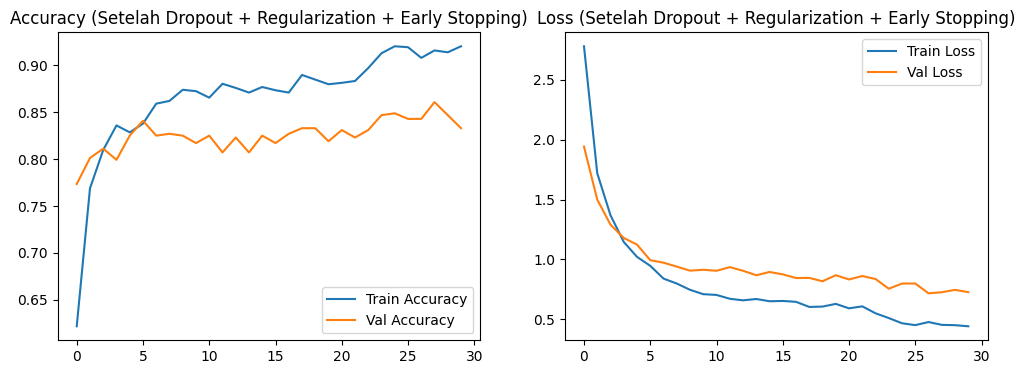

In [12]:
plot_history(history2, '(Setelah Dropout + Regularization + Early Stopping)')

### 8.2 Fine-Tuning Bertahap (Unfreeze Sebagian Layer)

Setelah classifier baru cukup stabil dari training 8.1, kita masuk ke tahap **Fine-Tuning** sesuai Strategy 2 pada slide *Using Pre-Trained Model* di materi: membuka (*unfreeze*) sebagian layer terakhir dari base model dan melatihnya bersama classifier baru.

**Kenapa hanya layer terakhir?**
Layer awal ResNet50V2 mendeteksi fitur umum (tepi, warna, tekstur) yang sudah relevan untuk dataset kita. Layer-layer akhirlah yang mendeteksi fitur lebih spesifik dan abstrak — inilah yang perlu disesuaikan untuk domain sampah. Membuka terlalu banyak layer berisiko merusak pengetahuan yang sudah ada (*catastrophic forgetting*).

**Learning rate sangat kecil (1e-5)**
Karena bobot base model sudah cukup bagus dari ImageNet, kita tidak perlu perubahan besar — cukup penyesuaian halus. Learning rate besar akan merusak bobot pre-trained yang sudah baik.

In [13]:
base_model2.trainable = True

# Bekukan layer awal, buka hanya 30 layer terakhir
for layer in base_model2.layers[:-30]:
    layer.trainable = False

model2.compile(
    optimizer=Adam(learning_rate=1e-5),  # LR sangat kecil untuk fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 578s 9s/step - accuracy: 0.8809 - loss: 0.6240 - val_accuracy: 0.8688 - val_loss: 0.6999 - learning_rate: 1.0000e-05
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 594s 9s/step - accuracy: 0.9027 - loss: 0.5488 - val_accuracy: 0.8410 - val_loss: 0.6993 - learning_rate: 1.0000e-05
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 575s 9s/step - accuracy: 0.9214 - loss: 0.5013 - val_accuracy: 0.8588 - val_loss: 0.6808 - learning_rate: 1.0000e-05
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 580s 9s/step - accuracy: 0.9338 - loss: 0.4599 - val_accuracy: 0.8668 - val_loss: 0.6993 - learning_rate: 1.0000e-05
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 626s 10s/step - accuracy: 0.9392 - loss: 0.4313 - val_accuracy: 0.8767 - val_loss: 0.6790 - learning_rate: 1.0000e-05
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 559s 9s/step - accuracy: 0.9373 - loss: 0.4248 - val_accuracy: 0.8628 - val_loss: 0.6734 - learning_rate: 1.0000e-05
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 560s 9s/step - accuracy: 0.9506

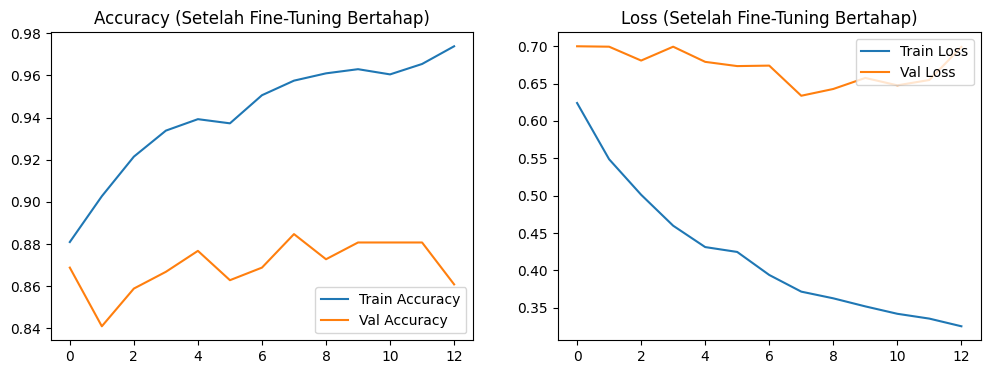

In [14]:
plot_history(history_fine, '(Setelah Fine-Tuning Bertahap)')

## 9. Evaluasi Akhir & Perbandingan
Pada tahap ini kita mengukur performa model final (setelah fine-tuning) secara kuantitatif:
- **Validation Accuracy & Loss**: ukuran performa keseluruhan pada data yang tidak digunakan saat training.
- **Gap train-val**: perbandingan sebelum vs sesudah penanganan overfitting.
- **Classification Report**: precision, recall, dan F1-score per kelas — memberikan gambaran kelas mana yang sulit diklasifikasikan.
- **Confusion Matrix**: visualisasi kesalahan klasifikasi antar kelas — diagonal = prediksi benar, off-diagonal = prediksi salah.

In [15]:
val_loss, val_acc = model2.evaluate(val_gen)
print(f'Validation Accuracy akhir : {val_acc:.4f}')
print(f'Validation Loss akhir     : {val_loss:.4f}')

final_train_acc2 = history_fine.history['accuracy'][-1]
final_val_acc2 = history_fine.history['val_accuracy'][-1]
gap2 = final_train_acc2 - final_val_acc2
print(f'\nGap akhir (Train - Val) setelah handling: {gap2:.4f}')

print('\nPerbandingan:')
print(f'  Gap sebelum handling overfitting : {gap:.4f}')
print(f'  Gap sesudah handling overfitting : {gap2:.4f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 80s 5s/step - accuracy: 0.8608 - loss: 0.6763
Validation Accuracy akhir : 0.8608
Validation Loss akhir     : 0.6763

Gap akhir (Train - Val) setelah handling: 0.1130

Perbandingan:
  Gap sebelum handling overfitting : 0.0957
  Gap sesudah handling overfitting : 0.1130


16/16 ━━━━━━━━━━━━━━━━━━━━ 84s 5s/step
              precision    recall  f1-score   support

   cardboard       0.95      0.97      0.96        80
       glass       0.87      0.89      0.88       100
       metal       0.87      0.96      0.91        82
       paper       0.83      0.88      0.85       118
     plastic       0.92      0.68      0.78        96
       trash       0.58      0.67      0.62        27

    accuracy                           0.86       503
   macro avg       0.84      0.84      0.83       503
weighted avg       0.87      0.86      0.86       503



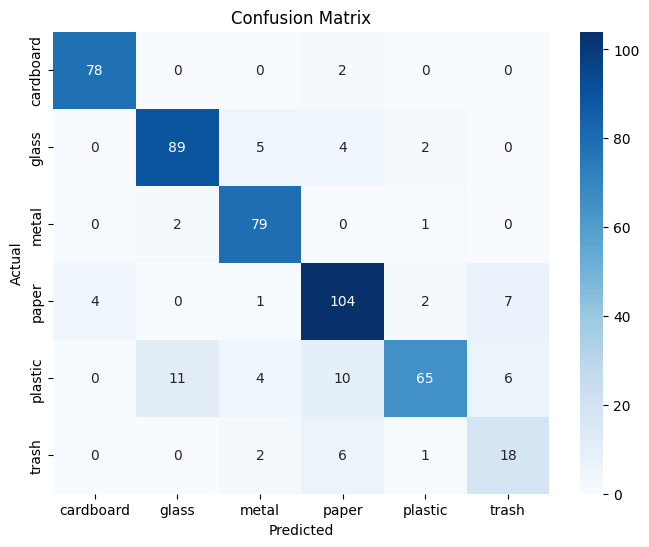

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_gen.reset()
y_pred_probs = model2.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

labels = list(class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 10. Kesimpulan

---

### 10.1 Ringkasan Eksperimen
Eksperimen ini membangun model klasifikasi jenis sampah menggunakan **Transfer Learning** dengan arsitektur **ResNet50V2** (pre-trained pada ImageNet) yang diadaptasi untuk dataset `TrashType_Image_Dataset` dari Kaggle. Pendekatan dua tahap diterapkan: Fixed Feature Extractor pada tahap awal, dilanjutkan Fine-Tuning bertahap pada tahap akhir.

---

### 10.2 Analisis Overfitting
Pada model tahap awal (Fixed Feature Extractor, 20 epoch tanpa early stopping), diperoleh:
- Train Accuracy: **96.05%**
- Validation Accuracy: **86.48%**
- **Gap: 9.57%** (tepat di bawah ambang 10%)

Secara teknis, program mendeteksi bahwa model *belum menunjukkan overfitting signifikan* (gap < 10%). Namun, selisih ~9.6% antara train dan val accuracy tetap menunjukkan bahwa model mulai cenderung menghafal data training. Hal ini wajar mengingat ukuran dataset yang relatif kecil (~2500 gambar) dan kompleksitas ResNet50V2 yang sangat dalam. Oleh karena itu, teknik penanganan overfitting tetap diterapkan secara proaktif.

---

### 10.3 Efektivitas Teknik Penanganan Overfitting
Teknik-teknik berikut diterapkan secara kombinasi dan terbukti membantu:

| Teknik | Peran |
|--------|-------|
| **Data Augmentation** | Memperbesar variasi data training secara artifisial, mengurangi risiko model menghafal gambar tertentu |
| **Dropout (0.5)** | Menonaktifkan 50% neuron secara acak tiap iterasi, memaksa jaringan membangun representasi yang lebih redundan dan robust |
| **L2 Regularization (0.01)** | Menambah penalti pada bobot besar dalam fungsi loss, mendorong model memilih solusi yang lebih sederhana |
| **Early Stopping (patience=5)** | Menghentikan training otomatis saat val_loss tidak membaik, mencegah model overfit lebih jauh |
| **ReduceLROnPlateau** | Menurunkan learning rate saat training stagnan, memungkinkan konvergensi yang lebih halus |
| **Fine-Tuning Bertahap** | Mengadaptasi 30 layer terakhir ResNet50V2 ke domain sampah dengan LR sangat kecil (1e-5), meningkatkan kemampuan ekstraksi fitur tanpa merusak bobot awal |

---

### 10.4 Kaitan dengan Materi Transfer Learning
Eksperimen ini secara langsung mempraktikkan konsep-konsep dari materi Week 13:
- **Source Domain → Target Domain**: pengetahuan dari ImageNet (klasifikasi objek umum) berhasil ditransfer ke domain baru (klasifikasi sampah) sesuai diagram *Knowledge Transfer* pada slide materi.
- **Fixed Feature Extractor**: diterapkan pada tahap awal dengan mem-freeze seluruh convolutional base.
- **Fine-Tuning**: diterapkan pada tahap lanjut dengan Strategy 2 (*train some layers, leave the others frozen*).
- **ResNet sebagai Pre-trained Model**: sesuai daftar model populer pada slide *Applications in Computer Vision*.

---

### 10.5 Rekomendasi Peningkatan
Jika ingin meningkatkan performa model lebih lanjut:
1. **Tambah data**: kumpulkan lebih banyak gambar sampah, terutama untuk kelas yang F1-score-nya rendah pada classification report di atas.
2. **Coba arsitektur lain**: EfficientNetB0 atau EfficientNetB3 menawarkan akurasi lebih tinggi dengan parameter lebih sedikit dibanding ResNet50V2.
3. **Sesuaikan jumlah layer yang di-unfreeze**: coba buka lebih sedikit (misal 10 layer) atau lebih banyak (50 layer) dan bandingkan hasilnya.
4. **Class weights**: jika distribusi kelas tidak merata, gunakan `class_weight` pada `model.fit()` agar model tidak bias ke kelas mayoritas.
5. **Test Time Augmentation (TTA)**: terapkan augmentasi juga saat inference, lalu rata-ratakan prediksi dari beberapa versi augmentasi gambar yang sama — biasanya meningkatkan akurasi 1-3%.